<h1>Train — DenseNet-121</h1>

Trains and evaluates DenseNet-121 using the tuned hyperparameters from `ARCH_HYPERPARAMS["densenet121"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1752 | Val: 495 | Test: 280


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["densenet121"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"DenseNet-121: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

DenseNet-121: micro batch = 16, accumulation steps = 3 (effective batch size ≈ 48, tuned value = 48)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with DenseNet-121)
# ---------------------------------------------------------
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
in_f = model.classifier.in_features
model.classifier = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[DenseNet-121] Using gradient accumulation: 3 micro-batches per optimizer step (effective batch size ≈ micro_batch x 3).


[DenseNet-121] Epoch   1/100 | LR: 3.44e-04 | train loss 0.7797 acc 0.635 | val loss 0.5625 acc 0.780 *


[DenseNet-121] Epoch   2/100 | LR: 3.44e-04 | train loss 0.4702 acc 0.801 | val loss 0.4167 acc 0.844 *


[DenseNet-121] Epoch   3/100 | LR: 3.44e-04 | train loss 0.3674 acc 0.844 | val loss 0.5385 acc 0.810


[DenseNet-121] Epoch   4/100 | LR: 3.44e-04 | train loss 0.3211 acc 0.854 | val loss 0.5201 acc 0.804


...

[DenseNet-121] Epoch   8/100 | LR: 3.44e-04 | train loss 0.1818 acc 0.912 | val loss 0.4979 acc 0.871


[DenseNet-121] Epoch   9/100 | LR: 3.44e-04 | train loss 0.2011 acc 0.920 | val loss 0.5614 acc 0.826


[DenseNet-121] Epoch  10/100 | LR: 3.44e-04 | train loss 0.1015 acc 0.953 | val loss 0.5524 acc 0.844


[DenseNet-121] Epoch  11/100 | LR: 3.44e-05 | train loss 0.1167 acc 0.949 | val loss 0.5876 acc 0.848


[DenseNet-121] Epoch  12/100 | LR: 3.44e-05 | train loss 0.0410 acc 0.984 | val loss 0.5131 acc 0.853

[DenseNet-121] No val loss improvement for 10 epochs — stopping early at epoch 12.

[DenseNet-121] Restored best checkpoint (val loss = 0.4167)


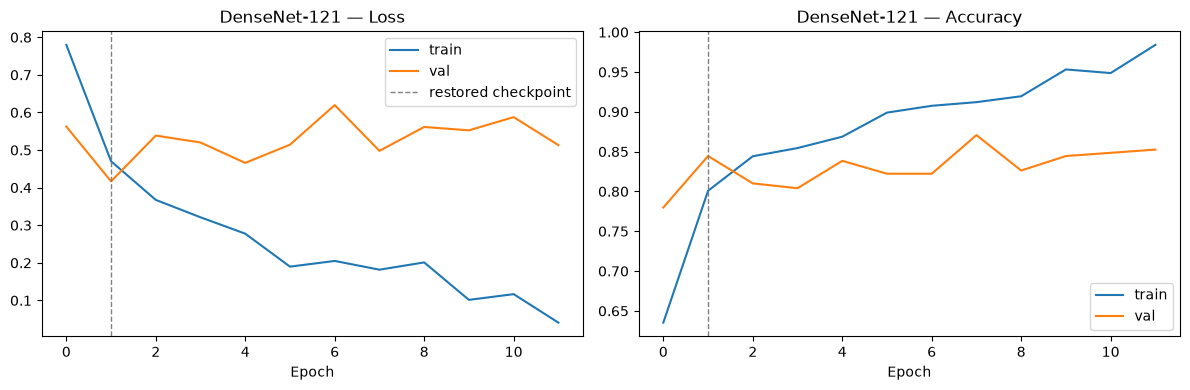

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "DenseNet-121", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "DenseNet-121")

## Evaluate on the test set

[DenseNet-121] Test accuracy: 0.843


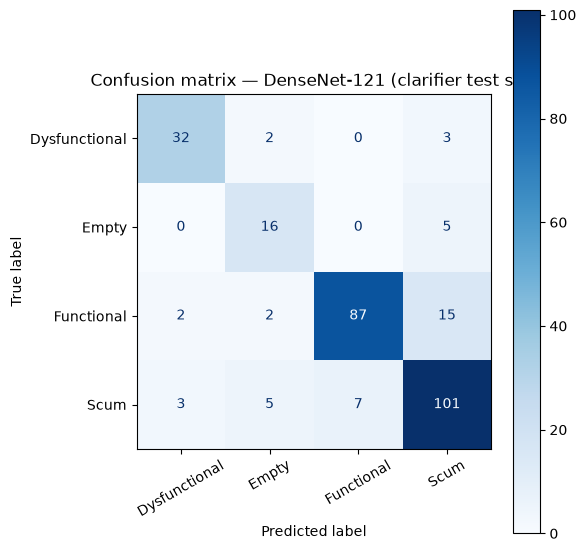

               precision    recall  f1-score   support

Dysfunctional      0.865     0.865     0.865        37
        Empty      0.640     0.762     0.696        21
   Functional      0.926     0.821     0.870       106
         Scum      0.815     0.871     0.842       116

     accuracy                          0.843       280
    macro avg      0.811     0.830     0.818       280
 weighted avg      0.850     0.843     0.845       280



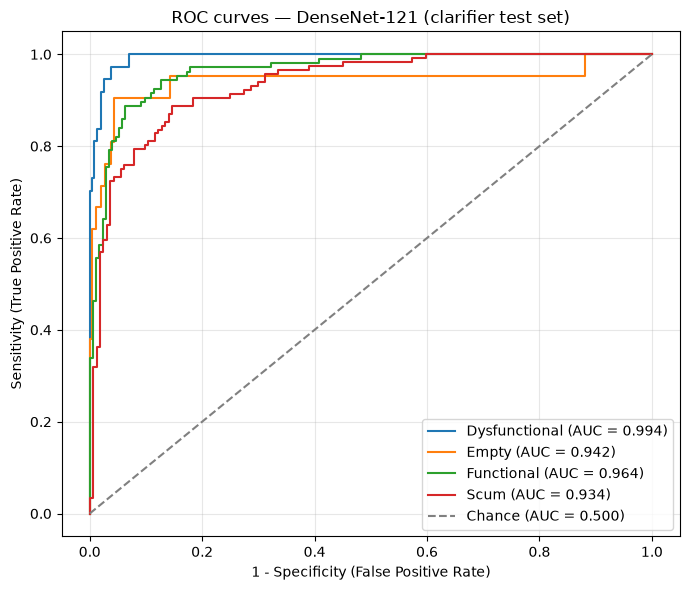

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.994
  Empty          : 0.942
  Functional     : 0.964
  Scum           : 0.934

Mean AUC (over 4/4 classes with test examples): 0.958


(np.float64(0.8428571428571429),
 {'Dysfunctional': 0.9936603269936604,
  'Empty': 0.9417172274315132,
  'Functional': 0.9643244415528085,
  'Scum': 0.9339255677039529})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "DenseNet-121", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("DenseNet-121", "densenet121")

Saved results to ../results/clarifier_noaug/results_clarifier_densenet121_stratified.pkl
Saved model weights to ../models/clarifier_densenet121_cnn.pt
